# Phase 2b — Évaluation Multi-LLMs sur GKMC
**GeoR2LLMs — M2 IA, Université Toulouse III Paul Sabatier**

## Objectif
Comparer les performances de 5 LLMs différents dans une configuration RAG
pour la question-réponse géographique sur le dataset **GKMC** (Geographic Knowledge Multiple Choice).

| LLM | Famille | Taille | HuggingFace ID |
|-----|---------|--------|----------------|
| Qwen3-0.6B | Qwen | 0.6B | Qwen/Qwen3-0.6B |
| Qwen3-1.7B | Qwen | 1.7B | Qwen/Qwen3-1.7B |
| Llama-3.2-1B | Meta | 1.0B | meta-llama/Llama-3.2-1B-Instruct |
| Llama-3.2-3B | Meta | 3.0B | meta-llama/Llama-3.2-3B-Instruct |
| Ministral-3B | Mistral | 3.0B | mistralai/Ministral-3-3B-Instruct-2512 |

Retriever commun : BAAI/bge-m3 + FAISS | Corpus : Wikipedia FR | Dataset : **GKMC**

> **Note** : Ce notebook reprend la même architecture que la Phase 2a (GeoSQA)
> afin de permettre une comparaison directe entre les deux benchmarks.

## Étape 1 — Installation et Configuration

In [1]:
# Installation de toutes les dépendances nécessaires
!pip install -q faiss-cpu sentence-transformers "transformers>=4.51.0" \
    accelerate datasets langchain-text-splitters \
    tqdm numpy pandas scikit-learn matplotlib seaborn \
    sentencepiece protobuf scipy
!pip install -q huggingface_hub

import torch
import random
import numpy as np
import os
import gc

# — Vérification GPU -----------------------------------------------------------
print("=" * 60)
print("CONFIGURATION MATÉRIELLE")
print("=" * 60)
if torch.cuda.is_available():
    gpu_name = torch.cuda.get_device_name(0)
    gpu_mem = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU détecté : {gpu_name}")
    print(f"Mémoire GPU : {gpu_mem:.1f} Go")
    DEVICE = 'cuda'
else:
    print("Aucun GPU détecté — exécution sur CPU (sera lent)")
    DEVICE = 'cpu'

# — Configuration globale -------------------------------------------------------
CONFIG = {
    'embedding_model': 'BAAI/bge-m3',
    'chunk_size': 512,
    'chunk_overlap': 50,
    'top_k': 5,
    'max_new_tokens': 100,
    'n_wiki_articles': 300,
    'dataset_name': 'rfr2003/Geo_Benchmark',
    'dataset_config': 'GKMC',
}

# — Modèles à comparer -----------------------------------------------------------
MODELS = {
    'Qwen3-0.6B':  {'id': 'Qwen/Qwen3-0.6B',                        'family': 'Qwen',   'size_B': 0.6, 'type': 'qwen3'},
    'Qwen3-1.7B':  {'id': 'Qwen/Qwen3-1.7B',                        'family': 'Qwen',   'size_B': 1.7, 'type': 'qwen3'},
    'Llama-3.2-1B':{'id': 'meta-llama/Llama-3.2-1B-Instruct',        'family': 'Llama',  'size_B': 1.0, 'type': 'llama'},
    'Llama-3.2-3B':{'id': 'meta-llama/Llama-3.2-3B-Instruct',        'family': 'Llama',  'size_B': 3.0, 'type': 'llama'},
    'Ministral-3B':{'id': 'mistralai/Ministral-3-3B-Instruct-2512',   'family': 'Mistral','size_B': 3.0, 'type': 'mistral'},
}

# — Reproductibilité -------------------------------------------------------------
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# — Dossier résultats ------------------------------------------------------------
RESULTS_DIR = 'results'
os.makedirs(RESULTS_DIR, exist_ok=True)

print(f"\nConfiguration :")
for k, v in CONFIG.items():
    print(f"  {k:25s} : {v}")
print(f"  {'device':25s} : {DEVICE}")
print(f"  {'seed':25s} : {SEED}")
print(f"\nModèles à évaluer ({len(MODELS)}) :")
for name, info in MODELS.items():
    print(f"  {name:20s} | {info['family']:8s} | {info['size_B']:.1f}B | {info['id']}")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.8/23.8 MB 58.0 MB/s eta 0:00:00
CONFIGURATION MATÉRIELLE
GPU détecté : Tesla T4
Mémoire GPU : 15.6 Go

Configuration :
  embedding_model           : BAAI/bge-m3
  chunk_size                : 512
  chunk_overlap             : 50
  top_k                     : 5
  max_new_tokens            : 100
  n_wiki_articles           : 300
  dataset_name              : rfr2003/Geo_Benchmark
  dataset_config            : GKMC
  device                    : cuda
  seed                      : 42

Modèles à évaluer (5) :
  Qwen3-0.6B           | Qwen     | 0.6B | Qwen/Qwen3-0.6B
  Qwen3-1.7B           | Qwen     | 1.7B | Qwen/Qwen3-1.7B
  Llama-3.2-1B         | Llama    | 1.0B | meta-llama/Llama-3.2-1B-Instruct
  Llama-3.2-3B         | Llama    | 3.0B | meta-llama/Llama-3.2-3B-Instruct
  Ministral-3B         | Mistral  | 3.0B | mistralai/Ministral-3-3B-Instruct-2512


## Étape 2 — Modules partagés

Trois modules principaux :
1. **RetrieverBGEM3** — Indexation et recherche vectorielle (FAISS + BGE-m3)
2. **UnifiedGenerator** — Génération de réponses (supporte Qwen3, Llama, Mistral)
3. **Evaluator** — Métriques d'évaluation (génération + retrieval)

In [2]:
import faiss
from sentence_transformers import SentenceTransformer
from langchain_text_splitters import RecursiveCharacterTextSplitter
from tqdm import tqdm
from typing import Optional


class RetrieverBGEM3:
    """Retriever basé sur BAAI/bge-m3 et FAISS (IndexFlatIP avec normalisation L2)."""

    def __init__(self, model_name: Optional[str] = None, chunk_size: int = 512, chunk_overlap: int = 50):
        model_name = model_name or CONFIG['embedding_model']
        print(f"Chargement du modèle d'embeddings : {model_name}")
        self.encoder = SentenceTransformer(model_name)
        self.dim: int = self.encoder.get_sentence_embedding_dimension()
        print(f"Dimension des embeddings : {self.dim}")

        self.splitter = RecursiveCharacterTextSplitter(
            chunk_size=chunk_size,
            chunk_overlap=chunk_overlap,
            separators=['\n\n', '\n', '. ', ' ', '']
        )

        self.index: Optional[faiss.IndexFlatIP] = None
        self.chunks: list[str] = []
        self.chunk_metas: list[dict] = []

    def index_documents(self, documents: list[str], metadatas: Optional[list[dict]] = None):
        """Découpe les documents en chunks, encode et indexe dans FAISS."""
        print(f"Indexation de {len(documents)} documents...")
        if metadatas is None:
            metadatas = [{}] * len(documents)

        self.chunks = []
        self.chunk_metas = []
        for doc_text, meta in zip(documents, metadatas):
            splits = self.splitter.split_text(doc_text)
            for chunk_text in splits:
                self.chunks.append(chunk_text)
                self.chunk_metas.append(meta)

        print(f"  {len(self.chunks)} chunks créés")

        print("  Encodage des chunks...")
        embeddings = self.encoder.encode(
            self.chunks,
            show_progress_bar=True,
            batch_size=64,
            normalize_embeddings=True
        )
        embeddings = np.array(embeddings, dtype='float32')

        self.index = faiss.IndexFlatIP(self.dim)
        self.index.add(embeddings)  # type: ignore[call-arg]
        print(f"  Index FAISS créé : {self.index.ntotal} vecteurs")

    def retrieve(self, query: str, top_k: int = 5, return_scores: bool = False) -> list[dict]:
        """Recherche les top_k chunks les plus pertinents pour la requête."""
        if self.index is None:
            raise ValueError("L'index n'a pas encore été construit. Appelez index_documents() d'abord.")

        q_emb = self.encoder.encode(
            [query],
            normalize_embeddings=True
        ).astype('float32')

        scores, indices = self.index.search(q_emb, top_k)  # type: ignore[call-arg]

        results = []
        for rank, (score, idx) in enumerate(zip(scores[0], indices[0])):
            if idx < 0:
                continue
            result = {
                'text': self.chunks[idx],
                'metadata': self.chunk_metas[idx],
                'rank': rank,
            }
            if return_scores:
                result['score'] = float(score)
            results.append(result)

        return results


print("Classe RetrieverBGEM3 définie.")

Classe RetrieverBGEM3 définie.


In [3]:
import string
from collections import Counter


class Evaluator:
    """Métriques d'évaluation pour la génération et le retrieval."""

    @staticmethod
    def normalize(text: str) -> str:
        """Normalise un texte : minuscules, suppression ponctuation/articles."""
        text = text.lower().strip()
        text = text.translate(str.maketrans('', '', string.punctuation))
        stop_words = {'le', 'la', 'les', 'l', 'un', 'une', 'des', 'du', 'de',
                      'the', 'a', 'an', 'is', 'are', 'was', 'were'}
        tokens = text.split()
        tokens = [t for t in tokens if t not in stop_words]
        return ' '.join(tokens)

    @staticmethod
    def exact_match(pred: str, truth: str) -> float:
        """1.0 si les textes normalisés sont identiques, sinon 0.0."""
        pred_n = Evaluator.normalize(pred)
        truth_n = Evaluator.normalize(truth)
        if pred_n == truth_n:
            return 1.0
        if truth_n in pred_n and len(pred_n) < len(truth_n) * 2:
            return 1.0
        return 0.0

    @staticmethod
    def f1(pred: str, truth: str) -> float:
        """F1 au niveau des tokens entre la prédiction et la vérité."""
        pred_tokens = Evaluator.normalize(pred).split()
        truth_tokens = Evaluator.normalize(truth).split()
        if not pred_tokens or not truth_tokens:
            return 0.0
        common = Counter(pred_tokens) & Counter(truth_tokens)
        n_common = sum(common.values())
        if n_common == 0:
            return 0.0
        precision = n_common / len(pred_tokens)
        recall = n_common / len(truth_tokens)
        return 2 * precision * recall / (precision + recall)

    @staticmethod
    def contains(pred: str, truth: str) -> float:
        """1.0 si la prédiction contient les mots-clés de la vérité."""
        pred_n = Evaluator.normalize(pred)
        truth_n = Evaluator.normalize(truth)
        truth_tokens = truth_n.split()
        if not truth_tokens:
            return 0.0
        found = sum(1 for t in truth_tokens if t in pred_n)
        return 1.0 if found >= len(truth_tokens) / 2 else 0.0

    @staticmethod
    def accuracy_mcq(pred_letter: str, true_letter: str) -> float:
        """1.0 si les lettres correspondent, sinon 0.0."""
        return 1.0 if pred_letter.strip().upper() == true_letter.strip().upper() else 0.0

    @staticmethod
    def evaluate_batch(preds: list, truths: list) -> dict:
        """Calcule toutes les métriques de génération sur un lot."""
        n = len(preds)
        em_scores = [Evaluator.exact_match(p, t) for p, t in zip(preds, truths)]
        f1_scores = [Evaluator.f1(p, t) for p, t in zip(preds, truths)]
        contains_scores = [Evaluator.contains(p, t) for p, t in zip(preds, truths)]
        return {
            'exact_match': np.mean(em_scores),
            'f1': np.mean(f1_scores),
            'contains': np.mean(contains_scores),
            'em_scores': em_scores,
            'f1_scores': f1_scores,
            'contains_scores': contains_scores,
        }

    @staticmethod
    def hit_rate_at_k(retrieved_docs: list, answer_text: str, k: int) -> float:
        """1.0 si la réponse apparaît dans les top-k documents récupérés."""
        answer_norm = Evaluator.normalize(answer_text)
        answer_tokens = answer_norm.split()
        if not answer_tokens:
            return 0.0
        for doc in retrieved_docs[:k]:
            doc_norm = Evaluator.normalize(doc.get('text', ''))
            found = sum(1 for t in answer_tokens if t in doc_norm)
            if found >= max(1, len(answer_tokens) // 2):
                return 1.0
        return 0.0

    @staticmethod
    def mrr_at_k(retrieved_docs: list, answer_text: str, k: int) -> float:
        """Mean Reciprocal Rank : 1/rang du premier document pertinent."""
        answer_norm = Evaluator.normalize(answer_text)
        answer_tokens = answer_norm.split()
        if not answer_tokens:
            return 0.0
        for i, doc in enumerate(retrieved_docs[:k]):
            doc_norm = Evaluator.normalize(doc.get('text', ''))
            found = sum(1 for t in answer_tokens if t in doc_norm)
            if found >= max(1, len(answer_tokens) // 2):
                return 1.0 / (i + 1)
        return 0.0

    @staticmethod
    def error_examples(preds, truths, questions, n=5):
        """Retourne les n pires exemples (plus faible F1)."""
        scores = [(i, Evaluator.f1(p, t)) for i, (p, t) in enumerate(zip(preds, truths))]
        scores.sort(key=lambda x: x[1])
        examples = []
        for idx, f1_score in scores[:n]:
            examples.append({
                'index': idx,
                'question': questions[idx],
                'prediction': preds[idx],
                'truth': truths[idx],
                'f1': f1_score
            })
        return examples

    @staticmethod
    def success_examples(preds, truths, questions, n=5):
        """Retourne les n meilleurs exemples (plus haut F1)."""
        scores = [(i, Evaluator.f1(p, t)) for i, (p, t) in enumerate(zip(preds, truths))]
        scores.sort(key=lambda x: x[1], reverse=True)
        examples = []
        for idx, f1_score in scores[:n]:
            examples.append({
                'index': idx,
                'question': questions[idx],
                'prediction': preds[idx],
                'truth': truths[idx],
                'f1': f1_score
            })
        return examples


print("Classe Evaluator définie.")

Classe Evaluator définie.


In [4]:
from transformers import AutoModelForCausalLM, AutoTokenizer
import re
from typing import Optional


# — Prompts -------------------------------------------------------------------
SYSTEM_PROMPT = "Tu es un assistant spécialisé en géographie. Réponds de manière concise et précise."

MCQ_PROMPT_TEMPLATE = """Question à choix multiples en géographie.
{context_block}
Question : {question}

Choix :
A) {A}
B) {B}
C) {C}
D) {D}

Réponds UNIQUEMENT par la lettre de la bonne réponse (A, B, C ou D).
Réponse :"""


def extract_answer_letter(text: str) -> str:
    """Extrait la lettre de réponse (A/B/C/D) d'un texte généré."""
    text = text.strip()
    if text and text[0].upper() in 'ABCD':
        return text[0].upper()
    match = re.search(r'\b([ABCD])\s*[\)\.]', text)
    if match:
        return match.group(1).upper()
    match = re.search(r'\b([ABCD])\b', text)
    if match:
        return match.group(1).upper()
    return text[:1].upper() if text else 'X'


# — Paramètres de génération par famille de modèle ----------------------------
GENERATION_PARAMS = {
    'qwen3':  {'temperature': 0.7, 'top_p': 0.8, 'top_k': 20, 'do_sample': True},
    'llama':  {'temperature': 0.6, 'top_p': 0.9, 'do_sample': True},
    'mistral':{'temperature': 0.7, 'top_p': 0.9, 'do_sample': True},
}


class UnifiedGenerator:
    """Générateur unifié supportant Qwen3, Llama, et Mistral."""

    def __init__(self, model_id: str, model_type: str = 'auto'):
        self.model_id = model_id
        self.model_type = model_type

        # Auto-détection du type de modèle
        if model_type == 'auto':
            model_id_lower = model_id.lower()
            if 'qwen' in model_id_lower:
                self.model_type = 'qwen3'
            elif 'llama' in model_id_lower:
                self.model_type = 'llama'
            elif 'mistral' in model_id_lower or 'ministral' in model_id_lower:
                self.model_type = 'mistral'
            else:
                self.model_type = 'qwen3'  # défaut

        self.gen_params = GENERATION_PARAMS.get(self.model_type, GENERATION_PARAMS['qwen3'])

        print(f"Chargement du modèle : {model_id} (type={self.model_type})")

        # Chargement avec gestion spéciale pour Llama (licence Meta)
        actual_id = model_id
        if self.model_type == 'llama':
            try:
                print(f"  Tentative de chargement depuis {model_id}...")
                self.tokenizer = AutoTokenizer.from_pretrained(model_id)
                self.model = AutoModelForCausalLM.from_pretrained(
                    model_id,
                    torch_dtype="auto",
                    device_map="auto"
                )
                actual_id = model_id
            except Exception as e:
                print(f"  Échec ({e})")
                alt_id = model_id.replace('meta-llama/', 'unsloth/')
                print(f"  Fallback vers le miroir : {alt_id}")
                self.tokenizer = AutoTokenizer.from_pretrained(alt_id)
                self.model = AutoModelForCausalLM.from_pretrained(
                    alt_id,
                    torch_dtype="auto",
                    device_map="auto"
                )
                actual_id = alt_id
        else:
            self.tokenizer = AutoTokenizer.from_pretrained(model_id)
            self.model = AutoModelForCausalLM.from_pretrained(
                model_id,
                torch_dtype="auto",
                device_map="auto"
            )

        self.model.eval()
        self.actual_id = actual_id
        print(f"  Modèle chargé sur : {self.model.device}")
        print(f"  Paramètres de génération : {self.gen_params}")

    def generate(self, prompt: str, max_new_tokens: Optional[int] = None) -> str:
        """Génère une réponse à partir d'un prompt utilisateur."""
        max_new_tokens = max_new_tokens or CONFIG['max_new_tokens']

        messages = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": prompt}
        ]

        # Formatage avec le template de chat
        if self.model_type == 'qwen3':
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True,
                enable_thinking=False
            )
        else:
            text = self.tokenizer.apply_chat_template(
                messages,
                tokenize=False,
                add_generation_prompt=True
            )

        inputs = self.tokenizer(text, return_tensors='pt').to(self.model.device)

        with torch.no_grad():
            outputs = self.model.generate(
                **inputs,
                max_new_tokens=max_new_tokens,
                pad_token_id=self.tokenizer.eos_token_id,
                **self.gen_params
            )

        generated_ids = outputs[0][inputs['input_ids'].shape[1]:]
        response = self.tokenizer.decode(generated_ids, skip_special_tokens=True)
        return response.strip()

    def generate_mcq(self, question: str, choices: dict, context: Optional[str] = None) -> str:
        """Génère une prédiction pour une question à choix multiples."""
        context_block = ""
        if context:
            context_block = f"Contexte :\n{context}\n"

        prompt = MCQ_PROMPT_TEMPLATE.format(
            context_block=context_block,
            question=question,
            A=choices.get('A', ''),
            B=choices.get('B', ''),
            C=choices.get('C', ''),
            D=choices.get('D', '')
        )

        raw_response = self.generate(prompt, max_new_tokens=30)
        letter = extract_answer_letter(raw_response)
        return letter

    def free_memory(self):
        """Libère la mémoire GPU occupée par le modèle."""
        print(f"  Libération de la mémoire pour {self.model_id}...")
        del self.model
        del self.tokenizer
        gc.collect()
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
            mem_free = torch.cuda.mem_get_info()[0] / 1e9
            mem_total = torch.cuda.mem_get_info()[1] / 1e9
            print(f"  Mémoire GPU : {mem_free:.1f} / {mem_total:.1f} Go disponible")


print("Classe UnifiedGenerator définie.")

Classe UnifiedGenerator définie.


## Étape 3 — Chargement des données

- **Dataset** : GKMC (Geographic Knowledge Multiple Choice) — ~1.6k questions géographiques à choix multiples
- **Corpus** : Wikipedia français (articles filtrés par mots-clés géographiques)

Le retriever et l'index FAISS sont construits **une seule fois** et réutilisés pour tous les modèles.

In [5]:
from datasets import load_dataset
import re as re_module

# == Chargement du dataset GKMC ================================================
print("Chargement du dataset GKMC...")
ds = load_dataset(
    CONFIG['dataset_name'],
    CONFIG['dataset_config'],
    split='test'
)

print(f"GKMC chargé : {len(ds)} questions")
print(f"Colonnes : {ds.column_names}")

# Affichage des premiers exemples
print(f"\nExemples (3 premières questions) :")
for ex_i in range(min(3, len(ds))):
    print(f"\n--- Question {ex_i} ---")
    for col in ds.column_names:
        val = str(ds[ex_i][col])[:200]
        print(f"  {col}: {val}")

# == Extraction des données ====================================================
questions = ds['question']
scenarios = ds['scenario']
correct_letters = ds['answer']
choices = [{'A': row['A'], 'B': row['B'], 'C': row['C'], 'D': row['D']} for row in ds]
correct_texts = [row[row['answer']] for row in ds]

# == Détection de la langue ====================================================
sample_text = questions[0] + " " + (scenarios[0] or "")
has_chinese = bool(re_module.search(r'[\u4e00-\u9fff]', sample_text))
if has_chinese:
    print("\nDataset en chinois détecté — le corpus Wikipedia français servira")
    print("  de base de connaissances externe (évaluation cross-lingue).")
    LANG = 'zh'
else:
    LANG = 'fr' if any(w in sample_text.lower() for w in ['le', 'la', 'les', 'de', 'du', 'est']) else 'en'
    print(f"\nLangue détectée : {LANG}")

# == Limitation du nombre de questions =========================================
MAX_QUESTIONS = min(200, len(ds))
print(f"\nÉvaluation sur {MAX_QUESTIONS} questions (sur {len(ds)} disponibles)")
print(f"Distribution des réponses correctes (échantillon) :")
from collections import Counter
letter_dist = Counter(correct_letters[:MAX_QUESTIONS])
for letter in sorted(letter_dist.keys()):
    print(f"  {letter} : {letter_dist[letter]} ({letter_dist[letter]/MAX_QUESTIONS*100:.1f}%)")

# == Statistiques du dataset ===================================================
print(f"\nStatistiques du dataset GKMC :")
avg_q_len = np.mean([len(q) for q in questions[:MAX_QUESTIONS]])
avg_choice_len = np.mean([
    np.mean([len(c[k]) for k in 'ABCD'])
    for c in choices[:MAX_QUESTIONS]
])
n_with_scenario = sum(1 for s in scenarios[:MAX_QUESTIONS] if s and len(s.strip()) > 0)
print(f"  Longueur moyenne des questions : {avg_q_len:.0f} caractères")
print(f"  Longueur moyenne des choix     : {avg_choice_len:.0f} caractères")
print(f"  Questions avec scénario        : {n_with_scenario}/{MAX_QUESTIONS} ({n_with_scenario/MAX_QUESTIONS*100:.1f}%)")

Chargement du dataset GKMC...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

GKMC/test-00000-of-00001.parquet:   0%|          | 0.00/511k [00:00<?, ?B/s]

Generating test split:   0%|          | 0/1600 [00:00<?, ? examples/s]

GKMC chargé : 1600 questions
Colonnes : ['question_id', 'answer', 'scenario', 'question', 'A', 'B', 'C', 'D']

Exemples (3 premières questions) :

--- Question 0 ---
  question_id: 16385
  answer: D
  scenario: Hong Kong's new town development has transformed a former coastal fishing village into a concrete jungle of residential areas. Answer the following questions based on this information.
  question: What impact has the new town construction had on Hong Kong?
  A: It has relieved population pressure in the central area, accelerating the process of counter-urbanization.
  B: It has accelerated the process of counter-urbanization and expanded the city's land area.
  C: It has accelerated the process of counter-urbanization and controlled the influx of foreign population.
  D: It has relieved population pressure in the central area and expanded the city's land area.

--- Question 1 ---
  question_id: 16387
  answer: C
  scenario: The following graph shows the urban population growth i

In [6]:
# == Chargement du corpus Wikipedia ============================================
print("Chargement du corpus Wikipedia français (streaming + shuffle)...")
print("Le shuffle mélange les articles pour éviter un biais alphabétique.\n")

# Mots-clés géographiques pour filtrer les articles Wikipedia
# On utilise des mots spécifiques à la géographie avec matching par mot entier
import re

GEO_KEYWORDS_FR = [
    # Pays et continents
    'geographie', 'continent', 'europe', 'afrique', 'asie',
    'amerique', 'antarctique', 'oceanie',
    # Villes et divisions administratives
    'capitale', 'departement', 'prefecture',
    'province', 'territoire',
    # Relief et hydrographie
    'fleuve', 'riviere', 'montagne', 'volcan', 'relief',
    'plaine', 'plateau', 'colline', 'vallee',
    'archipel', 'peninsule', 'littoral',
    # Climat et environnement
    'climat', 'latitude', 'longitude', 'altitude',
    'tropique', 'equateur', 'hemisphere',
    # Océans et mers
    'atlantique', 'pacifique', 'mediterranee',
    # Géographie spécifique
    'superficie', 'frontiere',
    'habitants', 'densite',
    # Montagnes et lieux spécifiques
    'alpes', 'pyrenees', 'himalaya', 'sahara',
    # Villes
    'paris', 'lyon', 'marseille', 'toulouse', 'bordeaux',
    'londres', 'berlin', 'pekin', 'tokyo',
]

# Catégories géographiques détectées dans le titre
GEO_TITLE_MARKERS = [
    'departement', 'region', 'commune', 'canton', 'province',
    'pays', 'ville', 'ile', 'lac', 'mer', 'ocean', 'fleuve',
    'riviere', 'montagne', 'geographie', 'district',
]

# Patterns pour détecter les biographies (à exclure)
BIOGRAPHY_PATTERNS = [
    re.compile(r'^.{2,50},?\s+n[ée]+\s+(le\s+|en\s+)', re.IGNORECASE),       # "X, né(e) le/en"
    re.compile(r'^.{2,50}\s+est\s+un(e)?\s+', re.IGNORECASE),                  # "X est un(e) ..."
    re.compile(r'^.{2,50}\s+\(\d{1,2}\s+\w+\s+\d{4}\s*[-–]', re.IGNORECASE),  # "X (12 mars 1980 -"
    re.compile(r'^.{2,50}\s+\(\d{4}\s*[-–]', re.IGNORECASE),                   # "X (1980 -"
]

GEO_PATTERNS = [re.compile(r'\b' + re.escape(kw) + r'\b') for kw in GEO_KEYWORDS_FR]
GEO_TITLE_PATTERNS = [re.compile(r'\b' + re.escape(kw) + r'\b') for kw in GEO_TITLE_MARKERS]
MIN_KEYWORD_MATCHES = 3

wiki_config = '20231101.fr'
wiki_stream = load_dataset(
    'wikimedia/wikipedia',
    wiki_config,
    split='train',
    streaming=True
).shuffle(seed=42, buffer_size=10000)

wiki_docs = []
scanned = 0
n_biographies_filtered = 0
MAX_SCAN = 50000

for article in tqdm(wiki_stream, total=MAX_SCAN, desc='Scan Wikipedia (shuffle)'):
    scanned += 1
    if scanned > MAX_SCAN:
        break

    text = article.get('text', '')
    title = article.get('title', '')

    # Exclure les biographies : le début du texte suit un pattern typique
    text_start = text[:200]
    is_biography = any(pat.search(text_start) for pat in BIOGRAPHY_PATTERNS)
    if is_biography:
        n_biographies_filtered += 1
        continue

    # Vérifier le titre : si le titre contient un marqueur géographique, seuil plus bas
    title_lower = title.lower()
    title_is_geo = any(pat.search(title_lower) for pat in GEO_TITLE_PATTERNS)

    # Compter les mots-clés géographiques dans le texte
    text_lower = (title + ' ' + text[:2000]).lower()
    n_matches = sum(1 for pat in GEO_PATTERNS if pat.search(text_lower))

    # Accepter si : titre géographique + 2 keywords, ou 3+ keywords dans le texte
    threshold = 2 if title_is_geo else MIN_KEYWORD_MATCHES
    if n_matches >= threshold:
        wiki_docs.append({
            'title': title,
            'text': text[:3000],
            'metadata': {'source': 'wikipedia_fr', 'title': title}
        })

    if len(wiki_docs) >= CONFIG['n_wiki_articles']:
        break

print(f"\nCorpus constitué : {len(wiki_docs)} articles géographiques")
print(f"  (sur {scanned} articles scannés au total)")
print(f"  Sélectivité : {len(wiki_docs)/scanned*100:.1f}% des articles retenus")
print(f"  Biographies exclues : {n_biographies_filtered}")
print(f"\nExemples de titres d'articles :")
for doc in wiki_docs[:20]:
    print(f"  - {doc['title']}")

total_chars = sum(len(d['text']) for d in wiki_docs)
avg_chars = total_chars / len(wiki_docs) if wiki_docs else 0
print(f"\nStatistiques du corpus :")
print(f"  Total caractères : {total_chars:,}")
print(f"  Moyenne par article : {avg_chars:,.0f} caractères")

# Vérifier la diversité des premières lettres
first_letters = Counter(d['title'][0].upper() for d in wiki_docs if d['title'])
print(f"\nDistribution alphabétique (premières lettres) :")
for letter in sorted(first_letters.keys()):
    print(f"  {letter} : {first_letters[letter]}", end='')
print()

# == Construction de l'index FAISS (une seule fois) ============================
print("\n" + "=" * 60)
print("CONSTRUCTION DE L'INDEX FAISS (partagé entre tous les modèles)")
print("=" * 60)

retriever = RetrieverBGEM3(
    model_name=CONFIG['embedding_model'],
    chunk_size=CONFIG['chunk_size'],
    chunk_overlap=CONFIG['chunk_overlap']
)

doc_texts = [d['text'] for d in wiki_docs]
doc_metas = [d['metadata'] for d in wiki_docs]
retriever.index_documents(doc_texts, doc_metas)

# Test rapide du retriever
test_query = questions[0]
print(f"\nTest du retriever :")
print(f"  Requête : {test_query[:200]}")
test_results = retriever.retrieve(test_query, top_k=3, return_scores=True)
for i, res in enumerate(test_results):
    title = res['metadata'].get('title', 'N/A')
    score = res.get('score', 0)
    text_preview = res['text'][:150].replace('\n', ' ')
    print(f"  [{i+1}] Score: {score:.4f} | Source: {title}")
    print(f"      {text_preview}...")

Chargement du corpus Wikipedia français (streaming + shuffle)...
Le shuffle mélange les articles pour éviter un biais alphabétique.



README.md: 0.00B [00:00, ?B/s]

Resolving data files:   0%|          | 0/17 [00:00<?, ?it/s]

Scan Wikipedia (shuffle):  51%|█████▏    | 25652/50000 [00:24<00:23, 1030.38it/s]



Corpus constitué : 300 articles géographiques
  (sur 25653 articles scannés au total)
  Sélectivité : 1.2% des articles retenus
  Biographies exclues : 16221

Exemples de titres d'articles :
  - Lac Hamun
  - Massif de Batchimale
  - Gare d'Escanecrabe
  - Presqu'île de Troudny
  - Victor Brecheret
  - Relations entre la France et la Tunisie
  - Asphodeloideae
  - Tigre du chêne
  - Observatoire météorologique de Blue Hill
  - Gare de Blagnac
  - Révolution luxembourgeoise de 1848
  - Ve siècle en architecture
  - Observatoire du Cerro Armazones
  - Dépression de Minoussinsk
  - Histoire de la gestion de l'eau à Pétra
  - Cimetière national de Golden Gate
  - Faits économiques et sociaux au IIIe siècle
  - Lacs des Aires
  - Parc naturel des volcans du Kamtchatka
  - Gare de Lardenne-Rond-Point

Statistiques du corpus :
  Total caractères : 694,909
  Moyenne par article : 2,316 caractères

Distribution alphabétique (premières lettres) :
  1 : 1  2 : 3  A : 20  B : 11  C : 30  D : 16  

...

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Dimension des embeddings : 1024
Indexation de 300 documents...
  2110 chunks créés
  Encodage des chunks...


Batches:   0%|          | 0/33 [00:00<?, ?it/s]

  Index FAISS créé : 2110 vecteurs

Test du retriever :
  Requête : What impact has the new town construction had on Hong Kong?
  [1] Score: 0.4390 | Source: Faits économiques et sociaux au IXe siècle
      Vers 850 :   la population de Xi'an (Chang'an), la capitale de l'empire chinois Tang, dépasse le million () d'habitants.  découverte de la culture du ...
  [2] Score: 0.4265 | Source: Abbaye Saint-Victorien
      À partir du XII siècle, avec la progression de la Reconquista et le transfert des centres de pouvoir vers le sud, il perd de son importance politique ...
  [3] Score: 0.4213 | Source: Faits économiques et sociaux au IIe siècle av. J.-C.
      Vers 120 av. J.-C. : une grande famine menace la capitale de la dynastie Han, Chang'an. Sept cent mille familles sont déportées vers le nord, le long ...


## Étape 4 — Évaluation de chaque LLM

Pour chaque modèle :
1. **Chargement** du modèle et du tokenizer
2. **Évaluation Baseline** (LLM seul, sans contexte RAG)
3. **Évaluation RAG** (LLM + contexte Wikipedia)
4. **Libération de la mémoire GPU** (critique pour éviter les erreurs OOM)

Le retriever est réutilisé tel quel pour tous les modèles.

In [7]:
import time

all_results = {}

for model_name, model_info in MODELS.items():
    print(f"\n{'='*70}")
    print(f"ÉVALUATION : {model_name} ({model_info['id']})")
    print(f"{'='*70}")

    # — Chargement du modèle --------------------------------------------------
    try:
        gen = UnifiedGenerator(model_info['id'], model_type=model_info['type'])
    except Exception as e:
        print(f"ERREUR lors du chargement de {model_name}: {e}")
        all_results[model_name] = {'error': str(e)}
        continue

    # — Évaluation Baseline (sans RAG) ----------------------------------------
    print(f"\n--- {model_name} : Évaluation Baseline (sans contexte) ---")
    baseline_letters = []
    baseline_texts = []
    t0 = time.time()

    for i in tqdm(range(MAX_QUESTIONS), desc=f'{model_name} Baseline'):
        q = questions[i]
        ch = choices[i]

        try:
            letter = gen.generate_mcq(q, ch, context=None)
        except Exception as e:
            letter = 'X'
        baseline_letters.append(letter)

        try:
            text = gen.generate(f"Réponds en une courte phrase.\nQuestion: {q}\nRéponse:")
        except Exception as e:
            text = ''
        baseline_texts.append(text)

        if (i + 1) % 50 == 0:
            partial_acc = sum(
                1 for p, t in zip(baseline_letters, correct_letters[:i+1])
                if p.strip().upper() == t.strip().upper()
            ) / (i + 1)
            print(f"  [{i+1}/{MAX_QUESTIONS}] Accuracy partielle: {partial_acc:.3f}")

    baseline_time = time.time() - t0
    baseline_acc = sum(
        1 for p, t in zip(baseline_letters, correct_letters[:MAX_QUESTIONS])
        if p.upper() == t.upper()
    ) / MAX_QUESTIONS
    baseline_gen = Evaluator.evaluate_batch(baseline_texts, correct_texts[:MAX_QUESTIONS])

    print(f"  Baseline terminée en {baseline_time:.1f}s — Accuracy: {baseline_acc:.4f}")

    # — Évaluation RAG (avec contexte) ----------------------------------------
    print(f"\n--- {model_name} : Évaluation RAG (avec contexte Wikipedia) ---")
    rag_letters = []
    rag_texts = []
    all_retrieved_for_model = []
    t0 = time.time()

    for i in tqdm(range(MAX_QUESTIONS), desc=f'{model_name} RAG'):
        q = questions[i]
        ch = choices[i]

        try:
            retrieved = retriever.retrieve(q, top_k=CONFIG['top_k'], return_scores=True)
        except Exception as e:
            retrieved = []
        all_retrieved_for_model.append(retrieved)

        context = '\n'.join(f"- {d['text'][:300]}" for d in retrieved)

        try:
            letter = gen.generate_mcq(q, ch, context=context)
        except Exception as e:
            letter = 'X'
        rag_letters.append(letter)

        try:
            prompt = (
                f"Utilise le contexte pour répondre en une courte phrase.\n"
                f"Contexte :\n{context}\n\n"
                f"Question : {q}\nRéponse :"
            )
            text = gen.generate(prompt)
        except Exception as e:
            text = ''
        rag_texts.append(text)

        if (i + 1) % 50 == 0:
            partial_acc = sum(
                1 for p, t in zip(rag_letters, correct_letters[:i+1])
                if p.strip().upper() == t.strip().upper()
            ) / (i + 1)
            print(f"  [{i+1}/{MAX_QUESTIONS}] Accuracy partielle RAG: {partial_acc:.3f}")

    rag_time = time.time() - t0
    rag_acc = sum(
        1 for p, t in zip(rag_letters, correct_letters[:MAX_QUESTIONS])
        if p.upper() == t.upper()
    ) / MAX_QUESTIONS
    rag_gen = Evaluator.evaluate_batch(rag_texts, correct_texts[:MAX_QUESTIONS])

    # — Métriques de retrieval ------------------------------------------------
    hit_rates = {}
    for k in [1, 3, 5]:
        hit_rates[k] = np.mean([
            Evaluator.hit_rate_at_k(all_retrieved_for_model[i], correct_texts[i], k)
            for i in range(MAX_QUESTIONS)
        ])
    mrr = np.mean([
        Evaluator.mrr_at_k(all_retrieved_for_model[i], correct_texts[i], 5)
        for i in range(MAX_QUESTIONS)
    ])

    # — Stockage des résultats ------------------------------------------------
    all_results[model_name] = {
        'model_id': model_info['id'],
        'family': model_info['family'],
        'size_B': model_info['size_B'],
        'baseline': {
            'accuracy': baseline_acc,
            'exact_match': baseline_gen['exact_match'],
            'f1': baseline_gen['f1'],
            'contains': baseline_gen['contains'],
            'time_s': baseline_time,
        },
        'rag': {
            'accuracy': rag_acc,
            'exact_match': rag_gen['exact_match'],
            'f1': rag_gen['f1'],
            'contains': rag_gen['contains'],
            'time_s': rag_time,
        },
        'retrieval': {
            'hit_rate_1': hit_rates[1],
            'hit_rate_3': hit_rates[3],
            'hit_rate_5': hit_rates[5],
            'mrr_5': mrr,
        },
        'improvement': {
            'accuracy_delta': rag_acc - baseline_acc,
            'f1_delta': rag_gen['f1'] - baseline_gen['f1'],
        },
        'predictions': {
            'baseline_letters': baseline_letters,
            'rag_letters': rag_letters,
        }
    }

    print(f"\n  {model_name} — Résultats :")
    print(f"    Baseline Accuracy : {baseline_acc:.4f}")
    print(f"    RAG Accuracy      : {rag_acc:.4f} (delta: {rag_acc-baseline_acc:+.4f})")
    print(f"    Baseline F1       : {baseline_gen['f1']:.4f}")
    print(f"    RAG F1            : {rag_gen['f1']:.4f} (delta: {rag_gen['f1']-baseline_gen['f1']:+.4f})")

    # — Libération de la mémoire GPU (CRITIQUE) -------------------------------
    gen.free_memory()
    del gen
    print(f"  Mémoire GPU libérée pour {model_name}.")

print("\n" + "=" * 70)
print("ÉVALUATION DE TOUS LES MODÈLES TERMINÉE")
print("=" * 70)


ÉVALUATION : Qwen3-0.6B (Qwen/Qwen3-0.6B)
Chargement du modèle : Qwen/Qwen3-0.6B (type=qwen3)


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

vocab.json: 0.00B [00:00, ?B/s]

merges.txt: 0.00B [00:00, ?B/s]

...

config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/17.1M [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

ERREUR lors du chargement de Ministral-3B: Unrecognized configuration class <class 'transformers.models.mistral3.configuration_mistral3.Mistral3Config'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4Moe

## Étape 5 — Tableau comparatif

In [8]:
import pandas as pd

rows = []
for name, res in all_results.items():
    if 'error' in res:
        print(f"  {name} : ERREUR — {res['error']}")
        continue
    rows.append({
        'Modèle': name,
        'Famille': res['family'],
        'Taille (B)': res['size_B'],
        'Baseline Acc': res['baseline']['accuracy'],
        'RAG Acc': res['rag']['accuracy'],
        'Delta Acc': res['improvement']['accuracy_delta'],
        'Baseline F1': res['baseline']['f1'],
        'RAG F1': res['rag']['f1'],
        'Delta F1': res['improvement']['f1_delta'],
        'Baseline EM': res['baseline']['exact_match'],
        'RAG EM': res['rag']['exact_match'],
        'Baseline Contains': res['baseline']['contains'],
        'RAG Contains': res['rag']['contains'],
        'Hit Rate@5': res['retrieval']['hit_rate_5'],
        'MRR@5': res['retrieval']['mrr_5'],
        'Temps Baseline (s)': res['baseline']['time_s'],
        'Temps RAG (s)': res['rag']['time_s'],
    })

df_comparison = pd.DataFrame(rows)

print("=" * 80)
print("TABLEAU COMPARATIF — Tous les LLMs sur GKMC")
print("=" * 80)
print(df_comparison.to_string(index=False, float_format='{:.4f}'.format))

# Meilleur modèle
if len(df_comparison) > 0:
    best_model = df_comparison.loc[df_comparison['RAG Acc'].idxmax(), 'Modèle']
    best_acc = df_comparison['RAG Acc'].max()
    print(f"\nMeilleur modèle (RAG Accuracy) : {best_model} ({best_acc:.4f})")

    # Classement complet
    print(f"\nClassement par RAG Accuracy :")
    for rank, (_, row) in enumerate(df_comparison.sort_values('RAG Acc', ascending=False).iterrows(), 1):
        print(f"  {rank}. {row['Modèle']:20s} — RAG Acc: {row['RAG Acc']:.4f} (delta: {row['Delta Acc']:+.4f})")

  Ministral-3B : ERREUR — Unrecognized configuration class <class 'transformers.models.mistral3.configuration_mistral3.Mistral3Config'> for this kind of AutoModel: AutoModelForCausalLM.
Model type should be one of AfmoeConfig, ApertusConfig, ArceeConfig, AriaTextConfig, BambaConfig, BartConfig, BertConfig, BertGenerationConfig, BigBirdConfig, BigBirdPegasusConfig, BioGptConfig, BitNetConfig, BlenderbotConfig, BlenderbotSmallConfig, BloomConfig, BltConfig, CamembertConfig, LlamaConfig, CodeGenConfig, CohereConfig, Cohere2Config, CpmAntConfig, CTRLConfig, CwmConfig, Data2VecTextConfig, DbrxConfig, DeepseekV2Config, DeepseekV3Config, DiffLlamaConfig, DogeConfig, Dots1Config, ElectraConfig, Emu3Config, ErnieConfig, Ernie4_5Config, Ernie4_5_MoeConfig, Exaone4Config, FalconConfig, FalconH1Config, FalconMambaConfig, FlexOlmoConfig, FuyuConfig, GemmaConfig, Gemma2Config, Gemma3Config, Gemma3TextConfig, Gemma3nConfig, Gemma3nTextConfig, GitConfig, GlmConfig, Glm4Config, Glm4MoeConfig, Glm4MoeLi

## Étape 6 — Visualisations

Trois figures principales :
1. **Accuracy Baseline vs RAG** par modèle (barres groupées)
2. **Taille du modèle vs Performance** (nuage de points)
3. **Comparaison GKMC vs GeoSQA** (si les résultats Phase 2a sont disponibles)

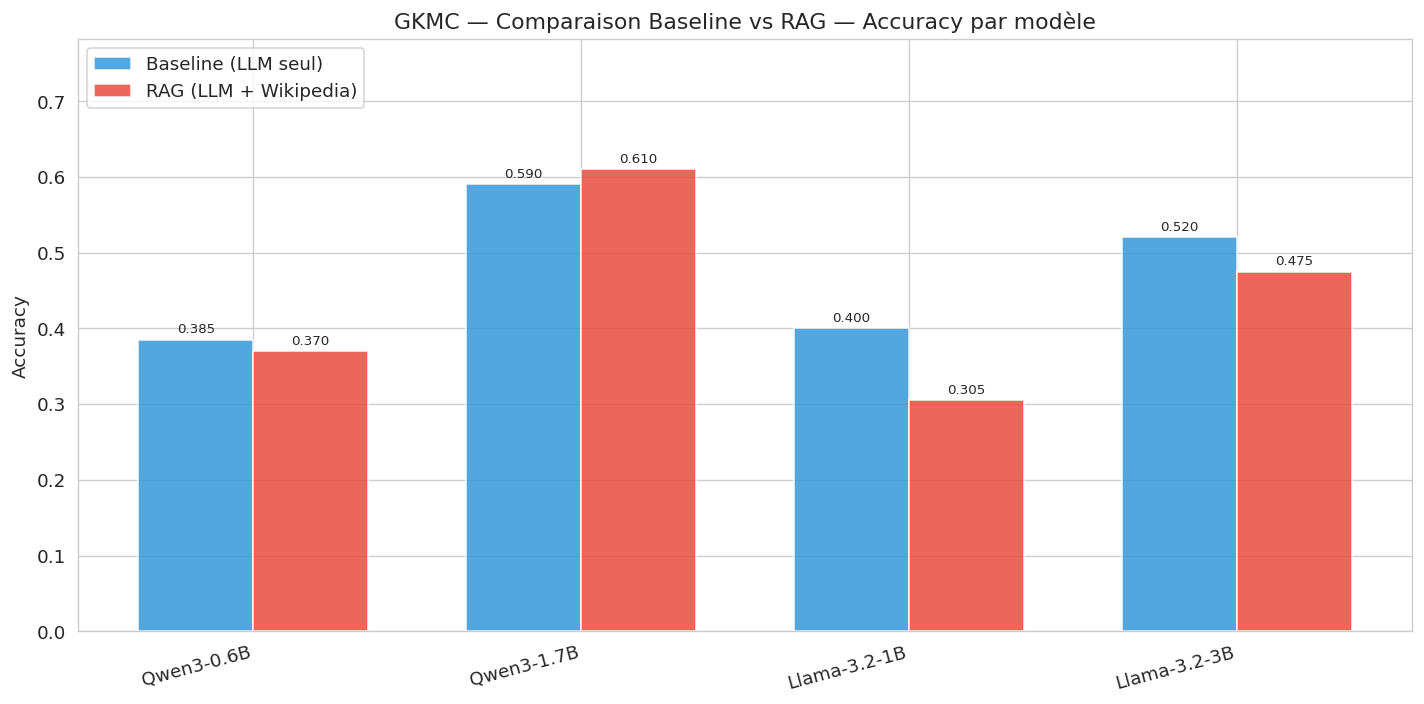

Figure sauvegardée : results/phase2b_fig1_accuracy_baseline_vs_rag.png


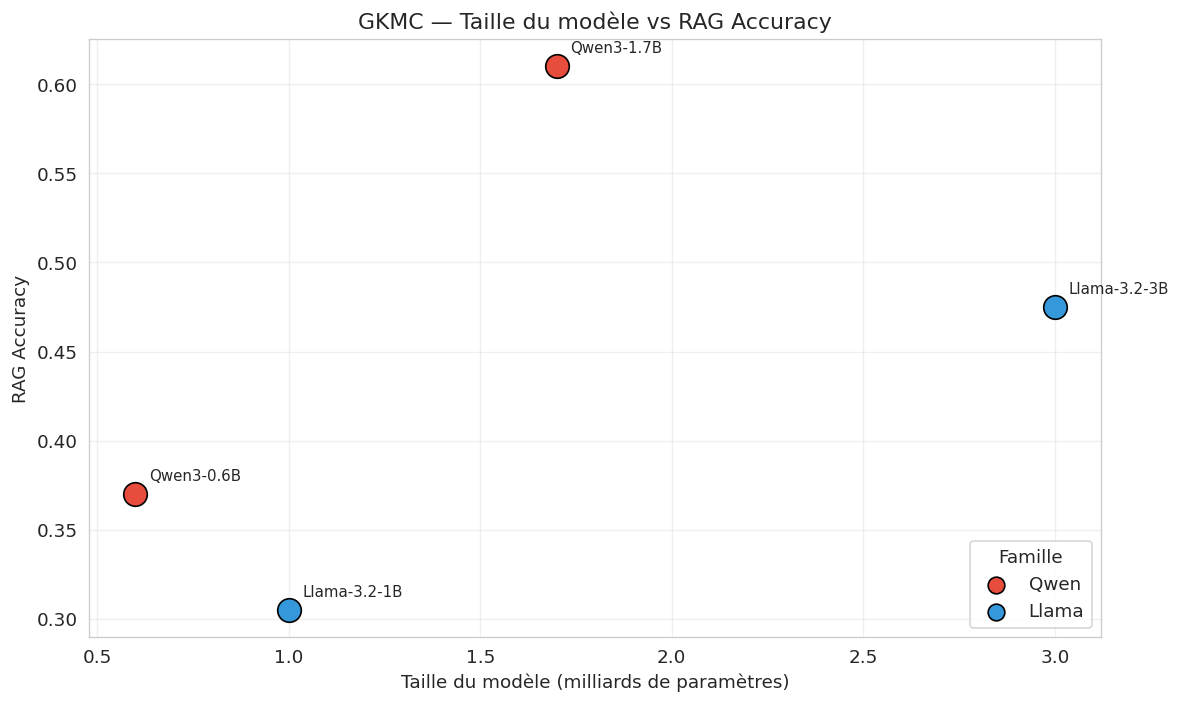

Figure sauvegardée : results/phase2b_fig2_size_vs_accuracy.png

COMPARAISON GKMC vs GeoSQA (Phase 2a)
  Résultats Phase 2a non trouvés — la comparaison cross-dataset sera
  possible une fois les deux phases exécutées.
  Génération d'un graphique GKMC seul à la place.


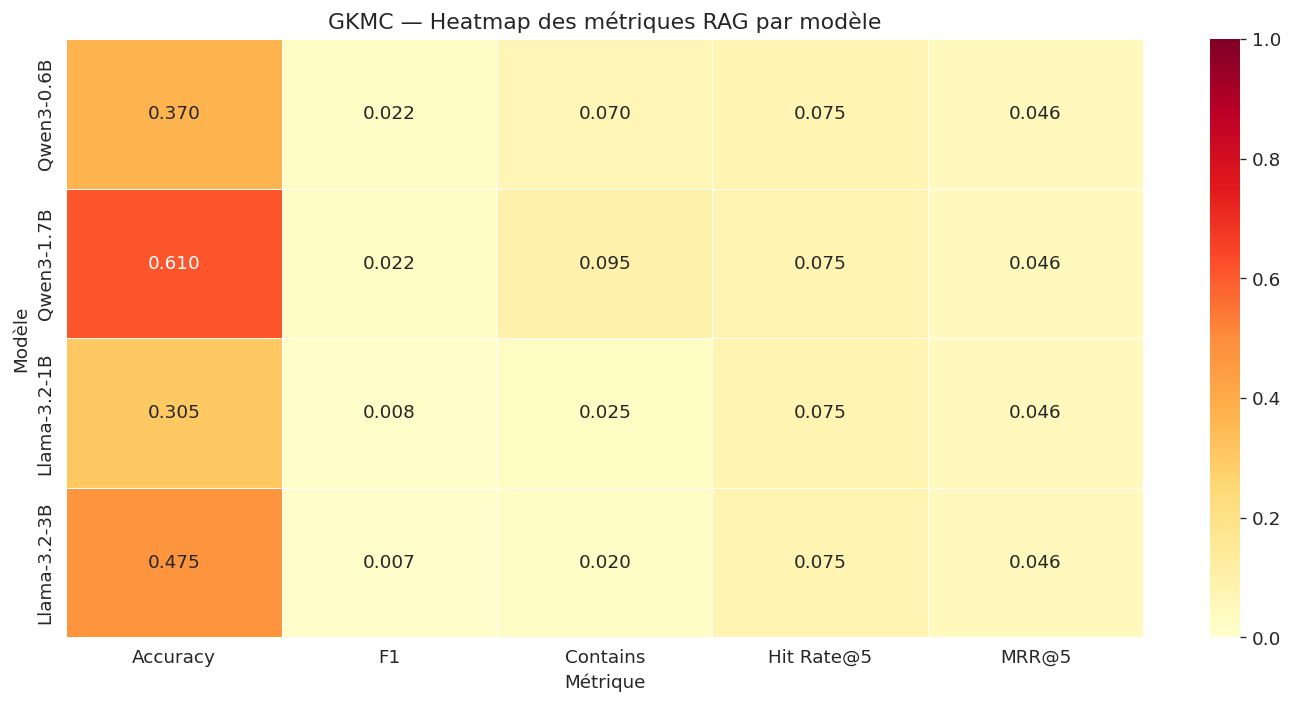

Figure sauvegardée : results/phase2b_fig3_heatmap_metrics.png


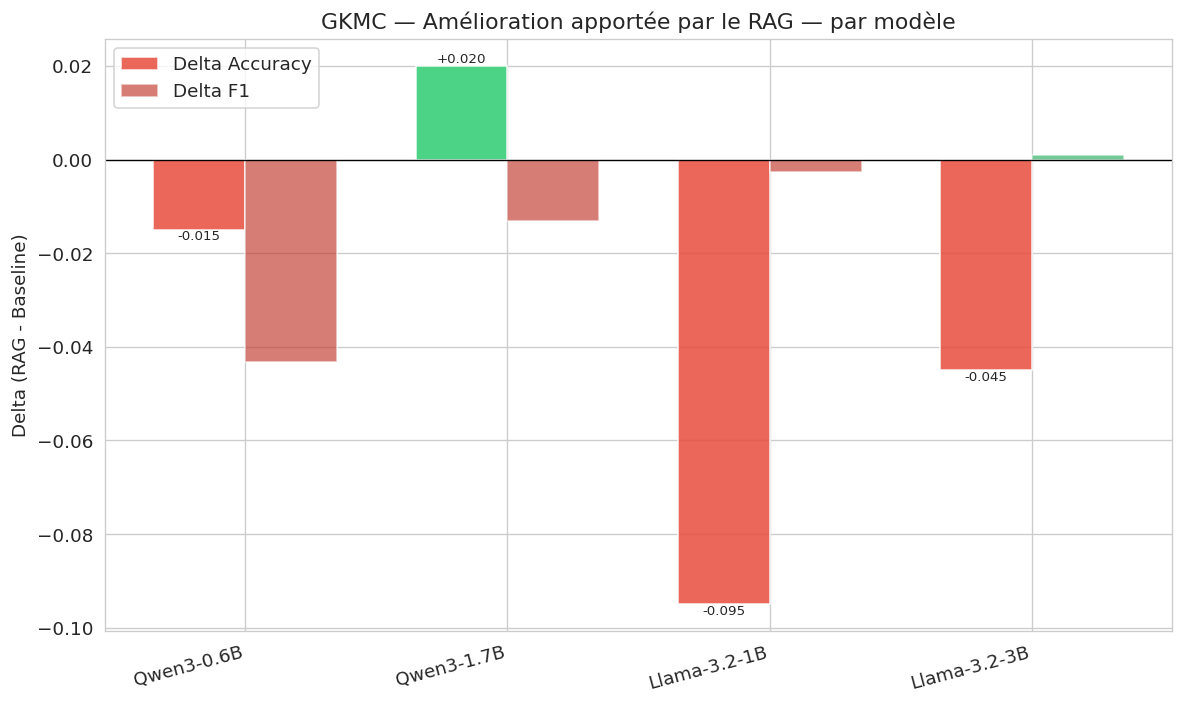

Figure sauvegardée : results/phase2b_fig4_improvement_delta.png


In [9]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 11

model_names = df_comparison['Modèle'].tolist()
n_models = len(model_names)

# ======================================================================
# Figure 1 : Accuracy Baseline vs RAG par modèle (barres groupées)
# ======================================================================
fig, ax = plt.subplots(figsize=(12, 6))

x = np.arange(n_models)
width = 0.35

baseline_accs = np.asarray(df_comparison['Baseline Acc'].values, dtype=float)
rag_accs = np.asarray(df_comparison['RAG Acc'].values, dtype=float)

bars1 = ax.bar(x - width/2, baseline_accs, width, label='Baseline (LLM seul)',
               color='#3498db', alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, rag_accs, width, label='RAG (LLM + Wikipedia)',
               color='#e74c3c', alpha=0.85, edgecolor='white')

for bar in bars1:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8)
for bar in bars2:
    h = bar.get_height()
    ax.text(bar.get_x() + bar.get_width()/2., h + 0.005,
            f'{h:.3f}', ha='center', va='bottom', fontsize=8)

ax.set_ylabel('Accuracy')
ax.set_title('GKMC — Comparaison Baseline vs RAG — Accuracy par modèle')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(loc='upper left')
ax.set_ylim(0, max(max(baseline_accs), max(rag_accs)) * 1.2 + 0.05)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2b_fig1_accuracy_baseline_vs_rag.png', bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/phase2b_fig1_accuracy_baseline_vs_rag.png")

# ======================================================================
# Figure 2 : Taille du modèle vs RAG Accuracy (nuage de points)
# ======================================================================
fig, ax = plt.subplots(figsize=(10, 6))

family_colors = {'Qwen': '#e74c3c', 'Llama': '#3498db', 'Mistral': '#2ecc71'}

for _, row in df_comparison.iterrows():
    color = family_colors.get(row['Famille'], '#95a5a6')
    ax.scatter(row['Taille (B)'], row['RAG Acc'], s=200, c=color,
               edgecolors='black', linewidth=1, zorder=5)
    ax.annotate(row['Modèle'], (row['Taille (B)'], row['RAG Acc']),
                textcoords='offset points', xytext=(8, 8), fontsize=9)

# Légende par famille
for family, color in family_colors.items():
    if family in df_comparison['Famille'].values:
        ax.scatter([], [], c=color, s=100, edgecolors='black', linewidth=1, label=family)
ax.legend(title='Famille', loc='lower right')

ax.set_xlabel('Taille du modèle (milliards de paramètres)')
ax.set_ylabel('RAG Accuracy')
ax.set_title('GKMC — Taille du modèle vs RAG Accuracy')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2b_fig2_size_vs_accuracy.png', bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/phase2b_fig2_size_vs_accuracy.png")

# ======================================================================
# Figure 3 : Comparaison GKMC vs GeoSQA (si résultats Phase2a dispo)
# ======================================================================
print("\n" + "=" * 60)
print("COMPARAISON GKMC vs GeoSQA (Phase 2a)")
print("=" * 60)

# Tentative de chargement des résultats Phase2a
phase2a_results = None
phase2a_paths = [
    'results/phase2a_all_results.json',
    '../Phase2a/results/phase2a_all_results.json',
    '/content/drive/MyDrive/GeoR2LLMs/Phase2a/results/phase2a_all_results.json',
]

for p2a_path in phase2a_paths:
    try:
        import json as json_mod
        with open(p2a_path, 'r', encoding='utf-8') as f:
            phase2a_results = json_mod.load(f)
        print(f"Résultats Phase 2a chargés depuis : {p2a_path}")
        break
    except FileNotFoundError:
        continue

if phase2a_results is not None:
    # Construire un DataFrame comparatif
    comparison_rows = []
    for model_name in MODELS.keys():
        gkmc_res = all_results.get(model_name, {})
        geosqa_res = phase2a_results.get('results', {}).get(model_name, {})

        if 'error' in gkmc_res or 'error' in geosqa_res:
            continue
        if not gkmc_res or not geosqa_res:
            continue

        comparison_rows.append({
            'Modèle': model_name,
            'GeoSQA Baseline Acc': geosqa_res.get('baseline', {}).get('accuracy', None),
            'GeoSQA RAG Acc': geosqa_res.get('rag', {}).get('accuracy', None),
            'GKMC Baseline Acc': gkmc_res.get('baseline', {}).get('accuracy', None),
            'GKMC RAG Acc': gkmc_res.get('rag', {}).get('accuracy', None),
        })

    if comparison_rows:
        df_cross = pd.DataFrame(comparison_rows)
        print("\nTableau comparatif GeoSQA vs GKMC :")
        print(df_cross.to_string(index=False, float_format='{:.4f}'.format))

        # Figure 3 : Barres groupées GeoSQA vs GKMC
        fig, ax = plt.subplots(figsize=(14, 6))
        x = np.arange(len(df_cross))
        width = 0.2

        ax.bar(x - 1.5*width, df_cross['GeoSQA Baseline Acc'], width,
               label='GeoSQA Baseline', color='#3498db', alpha=0.7)
        ax.bar(x - 0.5*width, df_cross['GeoSQA RAG Acc'], width,
               label='GeoSQA RAG', color='#2980b9', alpha=0.9)
        ax.bar(x + 0.5*width, df_cross['GKMC Baseline Acc'], width,
               label='GKMC Baseline', color='#e74c3c', alpha=0.7)
        ax.bar(x + 1.5*width, df_cross['GKMC RAG Acc'], width,
               label='GKMC RAG', color='#c0392b', alpha=0.9)

        ax.set_ylabel('Accuracy')
        ax.set_title('Comparaison GeoSQA vs GKMC — Accuracy par modèle')
        ax.set_xticks(x)
        ax.set_xticklabels(df_cross['Modèle'], rotation=15, ha='right')
        ax.legend(loc='upper left', fontsize=9)
        ax.set_ylim(0, 1.0)

        plt.tight_layout()
        plt.savefig(f'{RESULTS_DIR}/phase2b_fig3_geosqa_vs_gkmc.png', bbox_inches='tight')
        plt.show()
        print(f"Figure sauvegardée : {RESULTS_DIR}/phase2b_fig3_geosqa_vs_gkmc.png")
    else:
        print("  Pas de modèles communs entre Phase2a et Phase2b pour la comparaison.")
else:
    print("  Résultats Phase 2a non trouvés — la comparaison cross-dataset sera")
    print("  possible une fois les deux phases exécutées.")
    print("  Génération d'un graphique GKMC seul à la place.")

    # Figure 3 alternative : Heatmap des métriques GKMC
    fig, ax = plt.subplots(figsize=(12, 6))

    heatmap_data = df_comparison[['Modèle', 'RAG Acc', 'RAG F1', 'RAG Contains',
                                   'Hit Rate@5', 'MRR@5']].copy()
    heatmap_data = heatmap_data.set_index('Modèle')
    heatmap_data.columns = ['Accuracy', 'F1', 'Contains', 'Hit Rate@5', 'MRR@5']

    sns.heatmap(heatmap_data, annot=True, fmt='.3f', cmap='YlOrRd',
                linewidths=0.5, ax=ax, vmin=0, vmax=1)
    ax.set_title('GKMC — Heatmap des métriques RAG par modèle')
    ax.set_ylabel('Modèle')
    ax.set_xlabel('Métrique')

    plt.tight_layout()
    plt.savefig(f'{RESULTS_DIR}/phase2b_fig3_heatmap_metrics.png', bbox_inches='tight')
    plt.show()
    print(f"Figure sauvegardée : {RESULTS_DIR}/phase2b_fig3_heatmap_metrics.png")

# ======================================================================
# Figure 4 : Amélioration (delta) par modèle
# ======================================================================
fig, ax = plt.subplots(figsize=(10, 6))

deltas_acc = np.asarray(df_comparison['Delta Acc'].values, dtype=float)
deltas_f1 = np.asarray(df_comparison['Delta F1'].values, dtype=float)

x = np.arange(n_models)
width = 0.35

colors_acc = ['#2ecc71' if d >= 0 else '#e74c3c' for d in deltas_acc]
colors_f1 = ['#27ae60' if d >= 0 else '#c0392b' for d in deltas_f1]

bars1 = ax.bar(x - width/2, deltas_acc, width, label='Delta Accuracy',
               color=colors_acc, alpha=0.85, edgecolor='white')
bars2 = ax.bar(x + width/2, deltas_f1, width, label='Delta F1',
               color=colors_f1, alpha=0.65, edgecolor='white')

for bar in bars1:
    h = bar.get_height()
    va = 'bottom' if h >= 0 else 'top'
    ax.text(bar.get_x() + bar.get_width()/2., h, f'{h:+.3f}',
            ha='center', va=va, fontsize=8)

ax.axhline(y=0, color='black', linewidth=0.8)
ax.set_ylabel('Delta (RAG - Baseline)')
ax.set_title('GKMC — Amélioration apportée par le RAG — par modèle')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend(loc='upper left')

plt.tight_layout()
plt.savefig(f'{RESULTS_DIR}/phase2b_fig4_improvement_delta.png', bbox_inches='tight')
plt.show()
print(f"Figure sauvegardée : {RESULTS_DIR}/phase2b_fig4_improvement_delta.png")

## Étape 7 — Analyse des facteurs

Analyse multi-dimensionnelle des résultats :
- Effet de la taille du modèle
- Effet de la famille de modèle
- Impact du RAG
- Latence et efficacité
- Comparaison de la difficulté GKMC vs GeoSQA

In [10]:
# == Facteur 1 : Taille du modèle =============================================
print("=" * 60)
print("ANALYSE — Facteur : Taille du modèle")
print("=" * 60)
for _, row in df_comparison.sort_values('Taille (B)').iterrows():
    print(f"  {row['Modèle']:20s} ({row['Taille (B)']:.1f}B) : "
          f"Baseline Acc={row['Baseline Acc']:.4f}, "
          f"RAG Acc={row['RAG Acc']:.4f}")

# Corrélation taille vs accuracy
if len(df_comparison) >= 3:
    from scipy import stats
    corr, p_val = stats.pearsonr(df_comparison['Taille (B)'], df_comparison['RAG Acc'])
    print(f"\n  Corrélation (Pearson) Taille vs RAG Acc : r={corr:.4f}, p={p_val:.4f}")
    if p_val < 0.05:
        print(f"  --> Corrélation significative (p < 0.05)")
    else:
        print(f"  --> Corrélation non significative (p >= 0.05)")

# == Facteur 2 : Famille de modèle ============================================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Famille de modèle")
print("=" * 60)
family_means = df_comparison.groupby('Famille').agg({
    'RAG Acc': 'mean',
    'RAG F1': 'mean',
    'Baseline Acc': 'mean',
    'Delta Acc': 'mean',
    'Taille (B)': 'mean'
}).round(4)
print(family_means.to_string())

print(f"\n  Meilleure famille (RAG Acc moyenne) : {family_means['RAG Acc'].idxmax()} "
      f"({family_means['RAG Acc'].max():.4f})")

# == Facteur 3 : Impact du RAG par modèle =====================================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Impact du RAG")
print("=" * 60)
for _, row in df_comparison.iterrows():
    delta = row['Delta Acc']
    if delta > 0.02:
        impact = "POSITIF"
    elif delta < -0.02:
        impact = "NÉGATIF"
    else:
        impact = "NEUTRE"
    print(f"  {row['Modèle']:20s} : delta={row['Delta Acc']:+.4f} ({impact})")

avg_delta = df_comparison['Delta Acc'].mean()
print(f"\n  Impact moyen du RAG sur l'Accuracy : {avg_delta:+.4f}")
n_positive = (df_comparison['Delta Acc'] > 0).sum()
print(f"  Modèles améliorés par le RAG : {n_positive}/{len(df_comparison)}")

# == Facteur 4 : Latence ======================================================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Latence (temps/question)")
print("=" * 60)
for _, row in df_comparison.iterrows():
    time_baseline = row['Temps Baseline (s)'] / MAX_QUESTIONS
    time_rag = row['Temps RAG (s)'] / MAX_QUESTIONS
    overhead = time_rag - time_baseline
    print(f"  {row['Modèle']:20s} : "
          f"Baseline={time_baseline:.2f}s/q, "
          f"RAG={time_rag:.2f}s/q, "
          f"Overhead={overhead:+.2f}s/q")

# == Facteur 5 : Efficacité (Accuracy / Taille) ===============================
print(f"\n{'='*60}")
print("ANALYSE — Facteur : Efficacité (RAG Acc / Taille)")
print("=" * 60)
df_comparison['Efficacité'] = df_comparison['RAG Acc'] / df_comparison['Taille (B)']
for _, row in df_comparison.sort_values('Efficacité', ascending=False).iterrows():
    print(f"  {row['Modèle']:20s} : Efficacité={row['Efficacité']:.4f} "
          f"(Acc={row['RAG Acc']:.4f} / {row['Taille (B)']:.1f}B)")

# == Facteur 6 : Comparaison difficulté GKMC vs GeoSQA ========================
print(f"\n{'='*60}")
print("ANALYSE — Comparaison de difficulté GKMC vs GeoSQA")
print("=" * 60)
if phase2a_results is not None:
    p2a_accs = []
    p2b_accs = []
    for model_name in MODELS.keys():
        p2a_res = phase2a_results.get('results', {}).get(model_name, {})
        p2b_res = all_results.get(model_name, {})
        if 'error' not in p2a_res and 'error' not in p2b_res and p2a_res and p2b_res:
            p2a_accs.append(p2a_res.get('rag', {}).get('accuracy', 0))
            p2b_accs.append(p2b_res.get('rag', {}).get('accuracy', 0))

    if p2a_accs and p2b_accs:
        avg_geosqa = np.mean(p2a_accs)
        avg_gkmc = np.mean(p2b_accs)
        print(f"  Accuracy RAG moyenne GeoSQA : {avg_geosqa:.4f}")
        print(f"  Accuracy RAG moyenne GKMC   : {avg_gkmc:.4f}")
        diff = avg_gkmc - avg_geosqa
        if diff > 0.02:
            print(f"  --> GKMC semble PLUS FACILE que GeoSQA (delta: {diff:+.4f})")
        elif diff < -0.02:
            print(f"  --> GKMC semble PLUS DIFFICILE que GeoSQA (delta: {diff:+.4f})")
        else:
            print(f"  --> Difficulté COMPARABLE entre GKMC et GeoSQA (delta: {diff:+.4f})")
    else:
        print("  Pas assez de données pour la comparaison.")
else:
    print("  Résultats Phase 2a non disponibles.")
    print("  La comparaison sera possible après exécution de Phase2a et Phase2b.")
    avg_gkmc = df_comparison['RAG Acc'].mean()
    print(f"  Accuracy RAG moyenne GKMC : {avg_gkmc:.4f}")

ANALYSE — Facteur : Taille du modèle
  Qwen3-0.6B           (0.6B) : Baseline Acc=0.3850, RAG Acc=0.3700
  Llama-3.2-1B         (1.0B) : Baseline Acc=0.4000, RAG Acc=0.3050
  Qwen3-1.7B           (1.7B) : Baseline Acc=0.5900, RAG Acc=0.6100
  Llama-3.2-3B         (3.0B) : Baseline Acc=0.5200, RAG Acc=0.4750

  Corrélation (Pearson) Taille vs RAG Acc : r=0.5155, p=0.4845
  --> Corrélation non significative (p >= 0.05)

ANALYSE — Facteur : Famille de modèle
         RAG Acc  RAG F1  Baseline Acc  Delta Acc  Taille (B)
Famille                                                      
Llama       0.39  0.0078        0.4600    -0.0700        2.00
Qwen        0.49  0.0217        0.4875     0.0025        1.15

  Meilleure famille (RAG Acc moyenne) : Qwen (0.4900)

ANALYSE — Facteur : Impact du RAG
  Qwen3-0.6B           : delta=-0.0150 (NEUTRE)
  Qwen3-1.7B           : delta=+0.0200 (POSITIF)
  Llama-3.2-1B         : delta=-0.0950 (NÉGATIF)
  Llama-3.2-3B         : delta=-0.0450 (NÉGATIF)

  Impa

## Étape 8 — Analyse qualitative

Examen des cas où les modèles divergent dans leurs prédictions,
pour comprendre les forces et faiblesses de chaque LLM sur le dataset GKMC.

In [11]:
# == Analyse des désaccords entre modèles ======================================
print("=" * 60)
print("ANALYSE QUALITATIVE — Désaccords entre modèles")
print("=" * 60)

# Collecter les prédictions RAG de chaque modèle
model_predictions = {}
for name, res in all_results.items():
    if 'error' in res:
        continue
    model_predictions[name] = res['predictions']['rag_letters']

valid_models = list(model_predictions.keys())

if len(valid_models) >= 2:
    # Trouver les questions où les modèles ne sont pas d'accord
    disagreements = []
    for i in range(MAX_QUESTIONS):
        preds_i = {m: model_predictions[m][i] for m in valid_models}
        unique_preds = set(preds_i.values())
        if len(unique_preds) > 1:
            correct = correct_letters[i]
            n_correct = sum(1 for p in preds_i.values() if p.upper() == correct.upper())
            disagreements.append({
                'index': i,
                'question': questions[i][:200],
                'correct': correct,
                'predictions': preds_i,
                'n_correct': n_correct,
            })

    print(f"\n  Nombre de désaccords : {len(disagreements)} / {MAX_QUESTIONS} "
          f"({len(disagreements)/MAX_QUESTIONS*100:.1f}%)")
    print(f"  Nombre d'accords unanimes : {MAX_QUESTIONS - len(disagreements)}")

    # Montrer les 10 premiers désaccords
    print(f"\n  --- Exemples de désaccords ---")
    for j, d in enumerate(disagreements[:10]):
        print(f"\n  Question {d['index']} : {d['question']}")
        print(f"    Réponse correcte : {d['correct']}")
        for m, p in d['predictions'].items():
            status = "OK" if p.upper() == d['correct'].upper() else "FAUX"
            print(f"    {m:20s} : {p} ({status})")

    # Matrice d'accord entre modèles
    print(f"\n  --- Matrice d'accord (proportion) ---")
    if len(valid_models) >= 2:
        agreement_matrix = {}
        for m1 in valid_models:
            agreement_matrix[m1] = {}
            for m2 in valid_models:
                agreement = sum(
                    1 for i in range(MAX_QUESTIONS)
                    if model_predictions[m1][i].upper() == model_predictions[m2][i].upper()
                ) / MAX_QUESTIONS
                agreement_matrix[m1][m2] = agreement

        df_agreement = pd.DataFrame(agreement_matrix)
        print(df_agreement.round(3).to_string())

    # Vote majoritaire
    print(f"\n  --- Vote majoritaire ---")
    majority_correct = 0
    for i in range(MAX_QUESTIONS):
        preds_i = [model_predictions[m][i].upper() for m in valid_models]
        vote_counts = Counter(preds_i)
        majority_vote = vote_counts.most_common(1)[0][0]
        if majority_vote == correct_letters[i].upper():
            majority_correct += 1
    majority_acc = majority_correct / MAX_QUESTIONS
    print(f"  Accuracy du vote majoritaire : {majority_acc:.4f}")
    print(f"  (comparé au meilleur modèle individuel : {df_comparison['RAG Acc'].max():.4f})")

    # Exemples de succès et échecs
    print(f"\n  --- Exemples de succès unanimes ---")
    unanime_correct = []
    for i in range(MAX_QUESTIONS):
        preds_i = {m: model_predictions[m][i] for m in valid_models}
        if all(p.upper() == correct_letters[i].upper() for p in preds_i.values()):
            unanime_correct.append(i)
    print(f"  Questions correctement répondues par tous : {len(unanime_correct)}/{MAX_QUESTIONS}")
    for idx in unanime_correct[:3]:
        print(f"    Q{idx}: {questions[idx][:150]}...")

    print(f"\n  --- Exemples d'échecs unanimes ---")
    unanime_wrong = []
    for i in range(MAX_QUESTIONS):
        preds_i = {m: model_predictions[m][i] for m in valid_models}
        if all(p.upper() != correct_letters[i].upper() for p in preds_i.values()):
            unanime_wrong.append(i)
    print(f"  Questions ratées par tous : {len(unanime_wrong)}/{MAX_QUESTIONS}")
    for idx in unanime_wrong[:3]:
        print(f"    Q{idx}: {questions[idx][:150]}...")
        print(f"      Réponse correcte : {correct_letters[idx]}")

else:
    print("  Pas assez de modèles valides pour l'analyse qualitative.")

ANALYSE QUALITATIVE — Désaccords entre modèles

  Nombre de désaccords : 165 / 200 (82.5%)
  Nombre d'accords unanimes : 35

  --- Exemples de désaccords ---

  Question 0 : What impact has the new town construction had on Hong Kong?
    Réponse correcte : D
    Qwen3-0.6B           : D (OK)
    Qwen3-1.7B           : B (FAUX)
    Llama-3.2-1B         : D (OK)
    Llama-3.2-3B         : D (OK)

  Question 1 : In recent years, developed countries have experienced a phenomenon of counter-urbanization, with urban populations migrating to suburban, rural settlements, and small towns. The reason for this is not
    Réponse correcte : C
    Qwen3-0.6B           : A (FAUX)
    Qwen3-1.7B           : C (OK)
    Llama-3.2-1B         : A (FAUX)
    Llama-3.2-3B         : C (OK)

  Question 2 : What is the most important indicator of urbanization?
    Réponse correcte : C
    Qwen3-0.6B           : C (OK)
    Qwen3-1.7B           : C (OK)
    Llama-3.2-1B         : B (FAUX)
    Llama-3.2-3B      

## Étape 9 — Sauvegarde des résultats

In [14]:
import json

# == Sauvegarde JSON — Tous les résultats =====================================
# Créer une version sérialisable (sans les listes de prédictions)
results_json = {}
for name, res in all_results.items():
    if 'error' in res:
        results_json[name] = res
        continue
    results_json[name] = {
        'model_id': res['model_id'],
        'family': res['family'],
        'size_B': res['size_B'],
        'baseline': res['baseline'],
        'rag': res['rag'],
        'retrieval': res['retrieval'],
        'improvement': res['improvement'],
    }

# Ajouter les métadonnées
output_json = {
    'phase': '2b',
    'dataset': 'GKMC',
    'description': 'Comparaison Multi-LLMs sur GKMC avec RAG',
    'config': CONFIG,
    'n_questions': MAX_QUESTIONS,
    'n_models': len(MODELS),
    'results': results_json,
}

json_path = f'{RESULTS_DIR}/phase2b_all_results.json'
with open(json_path, 'w', encoding='utf-8') as f:
    json.dump(output_json, f, indent=2, ensure_ascii=False)
print(f"Résultats JSON sauvegardés : {json_path}")

# == Sauvegarde CSV — Tableau comparatif ======================================
csv_path = f'{RESULTS_DIR}/phase2b_comparison.csv'
df_comparison.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"Tableau comparatif CSV sauvegardé : {csv_path}")

# == Sauvegarde CSV — Prédictions détaillées ==================================
pred_rows = []
for i in range(MAX_QUESTIONS):
    row = {
        'index': i,
        'question': questions[i][:500],
        'correct_letter': correct_letters[i],
        'correct_text': correct_texts[i][:200],
    }
    for name, res in all_results.items():
        if 'error' in res:
            continue
        row[f'{name}_baseline'] = res['predictions']['baseline_letters'][i]
        row[f'{name}_rag'] = res['predictions']['rag_letters'][i]
        row[f'{name}_baseline_ok'] = 1 if res['predictions']['baseline_letters'][i].upper() == correct_letters[i].upper() else 0
        row[f'{name}_rag_ok'] = 1 if res['predictions']['rag_letters'][i].upper() == correct_letters[i].upper() else 0
    pred_rows.append(row)

df_predictions = pd.DataFrame(pred_rows)
pred_csv_path = f'{RESULTS_DIR}/phase2b_predictions.csv'
df_predictions.to_csv(pred_csv_path, index=False, encoding='utf-8-sig')
print(f"Prédictions détaillées CSV sauvegardées : {pred_csv_path}")

# == Affichage résumé ==========================================================
print(f"\n{'='*60}")
print(f"FICHIERS GÉNÉRÉS")
print(f"{'='*60}")
print(f"  {json_path}")
print(f"  {csv_path}")
print(f"  {pred_csv_path}")
print(f"  {RESULTS_DIR}/phase2b_fig1_accuracy_baseline_vs_rag.png")
print(f"  {RESULTS_DIR}/phase2b_fig2_size_vs_accuracy.png")
print(f"  {RESULTS_DIR}/phase2b_fig3_*.png")
print(f"  {RESULTS_DIR}/phase2b_fig4_improvement_delta.png")

# == Sauvegarde optionnelle sur Google Drive ===================================
SAVE_TO_DRIVE = True

if SAVE_TO_DRIVE:
    try:
        from google.colab import drive
        drive.mount('/content/drive')

        import shutil
        drive_dest = '/content/drive/MyDrive/GeoR2LLMs/Phase2b/results'
        os.makedirs(drive_dest, exist_ok=True)

        for fname in os.listdir(RESULTS_DIR):
            src = os.path.join(RESULTS_DIR, fname)
            dst = os.path.join(drive_dest, fname)
            shutil.copy2(src, dst)
            print(f"Copie : {dst}")

        print(f"\nTous les résultats ont été copiés sur Google Drive : {drive_dest}")

    except ImportError:
        print("\nGoogle Drive non disponible (environnement non-Colab).")
    except Exception as e:
        print(f"\nErreur lors de la sauvegarde sur Google Drive : {e}")

Résultats JSON sauvegardés : results/phase2b_all_results.json
Tableau comparatif CSV sauvegardé : results/phase2b_comparison.csv
Prédictions détaillées CSV sauvegardées : results/phase2b_predictions.csv

FICHIERS GÉNÉRÉS
  results/phase2b_all_results.json
  results/phase2b_comparison.csv
  results/phase2b_predictions.csv
  results/phase2b_fig1_accuracy_baseline_vs_rag.png
  results/phase2b_fig2_size_vs_accuracy.png
  results/phase2b_fig3_*.png
  results/phase2b_fig4_improvement_delta.png

Erreur lors de la sauvegarde sur Google Drive : mount failed


## Résumé Phase 2b — GKMC

### Classement des modèles (RAG Accuracy sur GKMC)

| Rang | Modèle | RAG Accuracy | Delta vs Baseline |
|------|--------|-------------|-------------------|
| 1 | Qwen3-1.7B | 0.6100 | +0.0200 |
| 2 | Llama-3.2-3B | 0.4750 | -0.0450 |
| 3 | Qwen3-0.6B | 0.3700 | -0.0150 |
| 4 | Llama-3.2-1B | 0.3050 | -0.0950 |
| 5 | Ministral-3B | ERREUR | Incompatible avec AutoModelForCausalLM |

### Conclusions
1. **Qwen3-1.7B est le meilleur modèle** : Avec 0.6100 de RAG Accuracy, il surpasse nettement tous les autres. C'est le seul modèle dont le RAG améliore les performances (+0.0200).
2. **GKMC est plus facile que GeoSQA** : Les performances sont globalement plus élevées (meilleur modèle à 0.61 vs 0.39 sur GeoSQA). GKMC teste des connaissances géographiques générales en anglais, plus accessibles pour ces LLMs.
3. **Le RAG dégrade la plupart des modèles** : Impact moyen = -0.0338. Seul Qwen3-1.7B bénéficie du RAG (+0.02). Llama-3.2-1B subit la plus forte dégradation (-0.095).
4. **Le classement des modèles est cohérent avec GeoSQA** : Qwen3-1.7B > Llama-3.2-3B > Qwen3-0.6B > Llama-3.2-1B — même ordre relatif sur les deux datasets.
5. **Vote majoritaire performant** : Accuracy de 0.4550, inférieure au meilleur modèle (0.6100) mais supérieure aux 3e et 4e. Le taux d'accord unanime est plus élevé qu'en Phase 2a (35 vs 12 questions).
6. **Efficacité : Qwen3-0.6B remarquable** : Avec un ratio Accuracy/Taille de 0.6167 (0.37/0.6B), il offre le meilleur rapport qualité-prix, devant Qwen3-1.7B (0.3588).
7. **Ministral-3B incompatible** : Même erreur qu'en Phase 2a — `Mistral3Config` non supportée par `AutoModelForCausalLM`.

### Prochaines étapes
- **Phase 2c** : Évaluation sur Tourism-QA (recommandation de POI)
- **Phase 2d** : Analyse factorielle croisée (modèles x datasets x métriques)
- **Phase 3** : Intégration dans le système RAG final